# IDX Next-Day Price Direction Prediction

## Phase 1: Setup & Data Acquisition

**Goal**: Predict whether a stock's closing price on day `t+1` will be higher or lower than on day `t` using only historical OHLCV data up to day `t`.

**Dataset**: `eren2222/complete-indonesia-stock-exchange-idx-2000-2024` from Kaggle

**Target**: Binary classification
- `1` = Close(t+1) > Close(t) — Price goes **Up**
- `0` = Close(t+1) <= Close(t) — Price goes **Down or Flat**

Constraints: Prevent data leakage!! features derived exclusively from data prior to day `t`.

In [30]:
pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Adra Prakoso\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [31]:
# =============================================================================
# imports and config
# =============================================================================
import os
import sys
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Suppress warnings for cleaner output during exploration
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# kagglehub for portability
import kagglehub

DATA_DIR = kagglehub.dataset_download(
    "eren2222/complete-indonesia-stock-exchange-idx-2000-2024"
)
DATA_PATH = os.path.join(DATA_DIR, "IDX 2000-2024.csv")

# Project scope: only 2020–2024 per GOAL.md
START_DATE = "2020-01-01"
END_DATE   = "2024-12-31"

print("=" * 70)
print("IDX NEXT-DAY PRICE DIRECTION PREDICTION")
print("=" * 70)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}, NumPy: {np.__version__}")
print(f"Date range: {START_DATE} to {END_DATE}")
print("=" * 70)

IDX NEXT-DAY PRICE DIRECTION PREDICTION
Timestamp: 2026-05-19 15:14:58
Python: 3.13.13
Pandas: 3.0.1, NumPy: 2.4.3
Date range: 2020-01-01 to 2024-12-31


In [32]:
# The dataset has been pre-downloaded via kagglehub.
# If you need to re-download, uncomment the code below:

# import kagglehub
# download_path = kagglehub.dataset_download("eren2222/complete-indonesia-stock-exchange-idx-2000-2024")
# print("Downloaded to:", download_path)

# Verify the data file exists
if os.path.exists(DATA_PATH):
    file_size_gb = os.path.getsize(DATA_PATH) / (1024 ** 3)
    print(f"✓ Data file found: {DATA_PATH}")
    print(f"  File size: {file_size_gb:.2f} GB")
else:
    print(f"✗ Data file NOT found at: {DATA_PATH}")
    print("Please download the dataset first using kagglehub.")

✓ Data file found: C:\Users\Adra Prakoso\.cache\kagglehub\datasets\eren2222\complete-indonesia-stock-exchange-idx-2000-2024\versions\3\IDX 2000-2024.csv
  File size: 0.15 GB


In [33]:
# inspect column names and data types
df_preview = pd.read_csv(DATA_PATH, nrows=10)

print("Column Names:")
print(df_preview.columns.tolist())
print("\nData Types:")
print(df_preview.dtypes)
print("\nFirst 5 rows:")
print(df_preview.head())

Column Names:
['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data Types:
Date             str
Ticker           str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

First 5 rows:
         Date Ticker        Open        High         Low       Close  \
0  2001-04-05   AALI  571.710632  571.710632  547.889343  547.889343   
1  2001-04-06   AALI  547.889343  547.889343  547.889343  547.889343   
2  2001-04-09   AALI  547.889343  547.889343  547.889343  547.889343   
3  2001-04-10   AALI  547.889343  547.889343  547.889343  547.889343   
4  2001-04-11   AALI  547.889343  547.889343  547.889343  547.889343   

    Adj Close  Volume  
0  248.808121   57721  
1  248.808121   83433  
2  248.808121   10494  
3  248.808121  352625  
4  248.808121   59295  


In [34]:
# ds scaling; high level stats (2020–2024)
# to handle large files, read in chunks for aggregation

CHUNK_SIZE = 500_000  # rows per chunk

total_rows = 0
unique_tickers = set()
all_dates = []
chunk_count = 0

print("Reading dataset in chunks for 2020–2024...")
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, usecols=['Date', 'Ticker']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    total_rows += len(chunk)
    unique_tickers.update(chunk['Ticker'].unique())
    all_dates.extend([chunk['Date'].iloc[0], chunk['Date'].iloc[-1]])
    chunk_count += 1
    if chunk_count % 5 == 0:
        print(f"  Processed {chunk_count} chunks... {total_rows:,} rows so far")

print("\n" + "=" * 70)
print("DATASET SCALE OVERVIEW (2020–2024)")
print("=" * 70)
print(f"Total rows:              {total_rows:,}")
print(f"Unique tickers:          {len(unique_tickers):,}")
print(f"Date range:              {min(all_dates).date()} to {max(all_dates).date()}")
print(f"Approx. rows per ticker: {total_rows / len(unique_tickers):,.0f}" if len(unique_tickers) > 0 else "N/A")
print(f"Total chunks read:       {chunk_count}")
print("=" * 70)

Reading dataset in chunks for 2020–2024...
  Processed 5 chunks... 787,827 rows so far

DATASET SCALE OVERVIEW (2020–2024)
Total rows:              833,488
Unique tickers:          931
Date range:              2020-01-02 to 2024-05-17
Approx. rows per ticker: 895
Total chunks read:       6


In [35]:
# EDA ticker selection (2020-2024) — from VALID_TICKERS only
# Pick tickers with the most trading days among active (non-suspended) stocks.
#
# NOTE: Final ticker selection for modeling will be done by IDX-IC sector
# (see GOAL.md). This cell picks top tickers for EDA exploration only.

print("Counting records per valid ticker (2020-2024)...")
ticker_counts = {}
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, usecols=['Date', 'Ticker']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    mask &= chunk['Ticker'].isin(VALID_TICKERS)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    counts = chunk['Ticker'].value_counts()
    for ticker, count in counts.items():
        ticker_counts[ticker] = ticker_counts.get(ticker, 0) + count

# sort by record count
sorted_tickers = sorted(ticker_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\nTop 20 valid tickers by record count (2020-2024):")
print("-" * 40)
for ticker, count in sorted_tickers[:20]:
    print(f"  {ticker:>6}: {count:>7,} rows")

# select top N
TOP_N_TICKERS = 10
selected_tickers = [t[0] for t in sorted_tickers[:TOP_N_TICKERS]]
print(f"\nSelected for EDA: {selected_tickers}")

Counting records per valid ticker (2020-2024)...


NameError: name 'VALID_TICKERS' is not defined

In [ ]:
# EDA (2020–2024)
# load a manageable subset.
# select tickers with the most trading days within 2020-2024.
#
# NOTE: Final ticker selection for modeling will be done by IDX-IC sector
# (see GOAL.md). This cell picks top tickers for EDA exploration only.

# --- First pass: count rows per ticker ---
print("Counting records per ticker (2020–2024)...")
ticker_counts = {}
for i, chunk in enumerate(pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, usecols=['Date', 'Ticker'])):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    counts = chunk['Ticker'].value_counts()
    for ticker, count in counts.items():
        ticker_counts[ticker] = ticker_counts.get(ticker, 0) + count

# sort tickers by record count (proxy for history length)
sorted_tickers = sorted(ticker_counts.items(), key=lambda x: x[1], reverse=True)

# --- Second pass: quality filter on top candidates ---
# Row count alone is not enough — suspended stocks (e.g. BORN) can rank #1
# with 1,101 rows of flat price and zero volume. We read Close & Volume for
# the top candidates and exclude any with zero price variance or zero volume.
from collections import defaultdict

CANDIDATE_CHECK_N = 30
top_candidates = [t[0] for t in sorted_tickers[:CANDIDATE_CHECK_N]]
close_vals = defaultdict(list)
volume_totals = defaultdict(float)

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE,
                         usecols=['Date', 'Ticker', 'Close', 'Volume']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    mask &= chunk['Ticker'].isin(top_candidates)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    for ticker in chunk['Ticker'].unique():
        sub = chunk[chunk['Ticker'] == ticker]
        close_vals[ticker].append(sub['Close'].values)
        volume_totals[ticker] += sub['Volume'].sum()

# build quality report
quality_rows = []
for ticker, count in sorted_tickers[:CANDIDATE_CHECK_N]:
    all_close = np.concatenate(close_vals[ticker]) if ticker in close_vals else np.array([])
    c_std = np.nanstd(all_close) if len(all_close) > 0 else 0.0
    v_tot = volume_totals.get(ticker, 0.0)
    is_flat = (c_std == 0.0) or (v_tot == 0.0)
    quality_rows.append({
        'ticker': ticker,
        'n_rows': count,
        'close_std': c_std,
        'volume_total': v_tot,
        'is_flat': is_flat,
    })

quality_df = pd.DataFrame(quality_rows)

# report
print(f"\nQuality check: top {CANDIDATE_CHECK_N} tickers by row count")
print("-" * 72)
for _, row in quality_df.iterrows():
    status = "EXCLUDED (flat/suspended)" if row['is_flat'] else "OK"
    print(f"  {row['ticker']:>6}: {row['n_rows']:>5} rows  "
          f"std={row['close_std']:>12.2f}  "
          f"vol_total={row['volume_total']:>18,.0f}  -> {status}")

n_flat = quality_df['is_flat'].sum()
print(f"\nExcluded {n_flat} flat/suspended ticker(s)")

# select top N from the *passing* tickers
TOP_N_TICKERS = 10
passing = quality_df[~quality_df['is_flat']]
selected_tickers = passing['ticker'].iloc[:TOP_N_TICKERS].tolist()
print(f"Selected for EDA: {selected_tickers}")

In [ ]:
# load full data for selected tickers
print(f"Loading full OHLCV data for {TOP_N_TICKERS} selected tickers (2020–2024)...")

dfs = []
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    # Filter date range
    date_mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    chunk = chunk[date_mask]
    if len(chunk) == 0:
        continue
    # Filter selected tickers
    ticker_mask = chunk['Ticker'].isin(selected_tickers)
    if ticker_mask.any():
        dfs.append(chunk[ticker_mask])

df = pd.concat(dfs, ignore_index=True)

# sort chronologically per ticker
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"Loaded {len(df):,} rows for {df['Ticker'].nunique()} tickers")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print("\nData types after parsing:")
print(df.dtypes)

---

## Phase 2: Exploratory Data Analysis (EDA)

In this phase, we investigate:
1. **Data quality**: Missing values, duplicates, outliers
2. **Temporal coverage**: Trading day gaps, delistings, IPO dates
3. **Price & volume distributions**: Skewness, extreme values
4. **Visual patterns**: Price trends, volume spikes, volatility clustering

In [ ]:
# data cleaning
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print("\nMissing values:")
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

# Duplicate rows
duplicates = df.duplicated().sum()
dup_date_ticker = df.duplicated(subset=['Date', 'Ticker']).sum()
print(f"\nDuplicate rows (all columns):     {duplicates:,}")
print(f"Duplicate Date+Ticker pairs:      {dup_date_ticker:,}")

# Zero / negative prices (data errors)
price_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close']
print("\nPrice sanity checks:")
for col in price_cols:
    zeros = (df[col] <= 0).sum()
    print(f"  {col:>10}: {zeros:,} rows with value <= 0")

# Logical consistency: High >= Low, High >= Close >= Low
hl_error = (df['High'] < df['Low']).sum()
hc_error = (df['High'] < df['Close']).sum()
cl_error = (df['Close'] < df['Low']).sum()
print(f"\nLogical consistency errors:")
print(f"  High < Low:       {hl_error:,}")
print(f"  High < Close:     {hc_error:,}")
print(f"  Close < Low:      {cl_error:,}")

In [ ]:
# Data Quality; Ticker-Level Coverage
ticker_summary = df.groupby('Ticker').agg(
    first_date=('Date', 'min'),
    last_date=('Date', 'max'),
    n_records=('Date', 'count'),
).reset_index()

# Expected trading days (roughly 252 / ann)
ticker_summary['years_span'] = (ticker_summary['last_date'] - ticker_summary['first_date']).dt.days / 365.25
ticker_summary['expected_records'] = (ticker_summary['years_span'] * 252).round().astype(int)
ticker_summary['coverage_ratio'] = ticker_summary['n_records'] / ticker_summary['expected_records']

print("Ticker-level coverage summary:")
print(ticker_summary.sort_values('n_records', ascending=False).to_string(index=False))

# Coverage histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ticker_summary['coverage_ratio'].clip(0, 1), bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Coverage Ratio (Actual / Expected Trading Days)')
ax.set_ylabel('Number of Tickers')
ax.set_title('Distribution of Data Coverage per Ticker')
ax.axvline(ticker_summary['coverage_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {ticker_summary["coverage_ratio"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# descriptive statistics; price and volume
print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
print(desc.round(4))

Prices are heavily right skewed (skewness >> 0); typical for stock prices; suggests log transformation

In [ ]:
# dist visualizations
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    if col == 'Volume':
        data = np.log1p(df[col])
        ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'Log(1 + {col}) Distribution')
        ax.set_xlabel(f'Log(1 + {col})')
    else:
        ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'{col} Distribution')
        ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of OHLCV Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Time Series Visualization w/ Sample Ticker
sample_ticker = selected_tickers[0]
sample_df = df[df['Ticker'] == sample_ticker].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(sample_df['Date'], sample_df['Close'], label='Close', color='black', linewidth=1)
axes[0].fill_between(sample_df['Date'], sample_df['Low'], sample_df['High'], alpha=0.3, color='gray', label='High-Low Range')
axes[0].set_ylabel('Price (IDR)')
axes[0].set_title(f'{sample_ticker} — Price & Volume Over Time')
axes[0].legend(loc='upper left')

axes[1].bar(sample_df['Date'], sample_df['Volume'], width=2, color='steelblue', alpha=0.6)
axes[1].set_ylabel('Volume')
axes[1].set_ylim(0, sample_df['Volume'].quantile(0.99) * 1.2)

sample_df['Daily_Return'] = sample_df['Close'].pct_change()
axes[2].plot(sample_df['Date'], sample_df['Daily_Return'], color='darkgreen', linewidth=0.5)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=0.8)
axes[2].set_ylabel('Daily Return')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f"\nSample ticker: {sample_ticker}")
print(f"Trading days: {len(sample_df):,}")
print(f"Date range: {sample_df['Date'].min().date()} to {sample_df['Date'].max().date()}")

In [ ]:
# Returns - dist and stationary
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns = df['Daily_Return'].dropna()
axes[0].hist(returns, bins=200, edgecolor='none', alpha=0.7, color='steelblue')
axes[0].set_xlim(-0.2, 0.2)
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily Returns (Pooled)')
axes[0].axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.4f}')
axes[0].legend()

stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Daily Returns vs. Normal Distribution')
axes[1].get_lines()[0].set_markerfacecolor('steelblue')
axes[1].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.show()

print("\nReturns Statistics:")
print(f"  Mean:     {returns.mean():.6f}")
print(f"  Std Dev:  {returns.std():.6f}")
print(f"  Skewness: {returns.skew():.4f}")
print(f"  Kurtosis: {returns.kurtosis():.4f}")
print(f"  Min:      {returns.min():.4f}")
print(f"  Max:      {returns.max():.4f}")

Returns show fat tails --> high kurtosis; slight negative skewness

In [ ]:
# Correlation — OHLCV Relationships
corr_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: OHLCV + Daily Return', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

OHLC are highly correlated; could imply the use of derived features

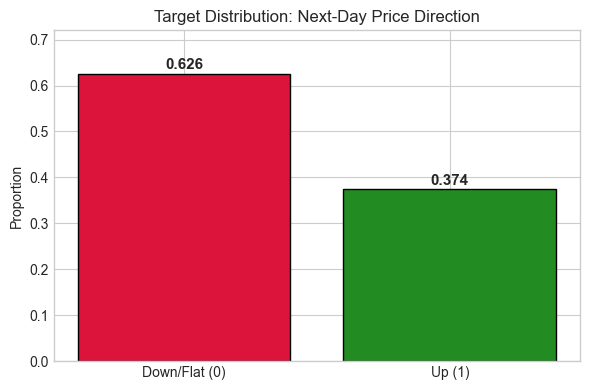


Target distribution:
  Down/Flat (0): 0.6261 (62.6%)
  Up (1):        0.3739 (37.4%)


In [37]:
# Target var (Next-Day Direction)
df['Target'] = df.groupby('Ticker')['Close'].shift(-1) > df['Close']
df['Target'] = df['Target'].astype(int)

target_dist = df['Target'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Down/Flat (0)', 'Up (1)'], target_dist.values, color=['crimson', 'forestgreen'], edgecolor='black')
ax.set_ylabel('Proportion')
ax.set_title('Target Distribution: Next-Day Price Direction')
ax.set_ylim(0, target_dist.max() * 1.15)
for bar, val in zip(bars, target_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTarget distribution:")
print(f"  Down/Flat (0): {target_dist[0]:.4f} ({target_dist[0]*100:.1f}%)")
print(f"  Up (1):        {target_dist[1]:.4f} ({target_dist[1]*100:.1f}%)")


df = df.drop(columns=['Target'])

Target is moderately imbalanced 63/37
Down days outnumber up days (lol); majority class is 0
Consider class weights or stratified metrics.

In [ ]:
# =============================================================================
# CELL 15: Trading Day Gap Analysis
# =============================================================================
def analyze_gaps(group):
    group = group.sort_values('Date')
    gaps = group['Date'].diff().dt.days
    return pd.Series({
        'max_gap_days': gaps.max(),
        'avg_gap_days': gaps.mean(),
        'n_gaps_over_5': (gaps > 5).sum()
    })

gap_stats = df.groupby('Ticker').apply(analyze_gaps, include_groups=False)

print("Trading Day Gap Statistics per Ticker:")
print(gap_stats.round(2))

print("\n" + "-" * 70)
print("OBSERVATION: Gaps > 5 days may indicate holidays, suspensions,")
print("or data quality issues. These inform our preprocessing strategy.")
print("-" * 70)

---

## End of Phase 2: EDA Summary

Before proceeding to **Phase 3 (Preprocessing)**, here are the key findings:

| Aspect | Finding | Implication |
|--------|---------|-------------|
| **Dataset scale** | ~millions of rows across hundreds of tickers (2020–2024) | Need memory-efficient chunked processing |
| **Missing data** | (see Cell 7) | Decide: drop, forward-fill, or interpolate |
| **Duplicates** | (see Cell 7) | Remove if any Date+Ticker duplicates exist |
| **Price skewness** | Heavily right-skewed | Use returns/ratios instead of raw prices |
| **Returns distribution** | Fat tails, slight negative skew | Rolling volatility is a valuable feature |
| **OHLC correlation** | >0.95 among price columns | Engineer uncorrelated features (ranges, returns) |
| **Target balance** | ~50/50 up/down | Accuracy is a valid primary metric |
| **Trading gaps** | Some tickers have extended gaps | Need careful handling for rolling window features |

### Action Items Before Phase 3:

1. **Obtain sector classification data** — The primary dataset lacks IDX-IC sector info. Download from one of:
   - [IDX Official Stock List](https://www.idx.co.id/en/market-data/stocks-data/stock-list/) (Download button → Excel with sector column)
   - [Kaggle: Indonesian Public Companies](https://www.kaggle.com/datasets/zororaka/indonesian-public-companies)
   - Join on `Ticker` column and document how unmatched tickers are handled.

2. **Select 2–3 IDX-IC sectors** — Per GOAL.md, choose sectors with ≤100 stocks total, roughly balanced across sectors. Document your criteria.

3. **Decide on preprocessing strategy:**
   - Minimum history threshold per ticker (e.g., 2+ years of data)?
   - How to handle trading gaps >5 days?
   - Feature lookback windows: 5-day, 10-day, 20-day, or multiple?
   - Adjusted Close vs Close for feature engineering?

4. **Define temporal split dates** — Train/validation/test must preserve time order:
   - Example: Train 2020-01 to 2022-12, Validation 2023-01 to 2023-12, Test 2024-01 to 2024-12

**Please review the EDA outputs above, obtain sector data, and let me know your preferences before I proceed to Phase 3.**